In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time
import sys

# Effective hyperdegree SIS model and Gillespie simulation

This notebook showcases the main functions of the `HO_effective_degree` library, which was used to obtain the results presented in the paper *"Unveiling the impact of cross-order hyperdegree correlations in contagion processes on hypergraphs"*.

The library implements the effective hyperdegree model, which tracks the variables $S_{k_1}^{k_2}(t)$ and $I_{k_1}^{k_2}(t)$ — the number of susceptible and infected nodes with hyperdegrees $k_1$ and $k_2$ at time $t$, respectively.



In [2]:
sys.path.insert(1,'Libraries/')

from Configurational_model_HO import* #one for the configurational mdoel and another
from Overlap_func import* #for calcualte overlap of higher order netowks
from HO_effective_degree import* #contains then necesaryt functions for effective hyperdegree

First, we generate a higher-order network using the configurational model described in `configurational_model_use.ipynb`.

In [3]:
'''Create the Hyergraph using the configurational model'''
# Define the desired degree for pairwise (k1) and three-body (k2) interactions
k1 = 5
k2 = 3
N = 1000  # Number of nodes in the hypergraph

# Create homogeneous degree sequences: every node has the same k1 and k2
sample_k1=np.random.poisson(lam=k1,size=N)
sample_k2=np.random.poisson(lam=k2,size=N)

# Shuffle the degree sequences (useful for the stub-matching process in the configurational model)
random.shuffle(sample_k1)
random.shuffle(sample_k2)

# Generate the hypergraph using the configurational model,
# returning pairwise edges and three-body (triangle) hyperedges
edges, triples = configurational_model_hypergraph(sample_k1, sample_k2, N)

# Combine pairwise and three-body interactions into a single list of hyperedges
hyper_edges = [*edges, *triples]

print(triples)


[[307, 915, 369], [550, 389, 872], [751, 548, 265], [66, 765, 139], [545, 934, 748], [569, 197, 42], [509, 273, 482], [147, 263, 292], [314, 661, 993], [362, 887, 405], [84, 272, 477], [895, 829, 505], [497, 363, 564], [214, 147, 350], [580, 63, 891], [686, 303, 498], [936, 688, 843], [905, 693, 109], [657, 588, 654], [11, 109, 973], [650, 500, 414], [503, 845, 850], [835, 464, 923], [183, 538, 38], [618, 882, 708], [590, 468, 811], [942, 647, 111], [474, 122, 852], [197, 172, 568], [408, 386, 472], [200, 607, 246], [625, 46, 241], [288, 496, 303], [123, 772, 635], [102, 396, 86], [472, 673, 614], [522, 659, 885], [810, 775, 700], [441, 977, 450], [600, 726, 74], [388, 399, 958], [635, 15, 75], [435, 568, 296], [814, 809, 729], [13, 195, 281], [492, 888, 660], [554, 522, 672], [360, 861, 9], [882, 606, 522], [18, 217, 449], [541, 366, 824], [515, 929, 354], [315, 739, 810], [819, 970, 793], [140, 183, 605], [730, 458, 231], [52, 887, 322], [853, 526, 905], [583, 581, 255], [357, 189, 7

# Stochastic Gillespie simulations

We use stochastic simulations to assess the accuracy of the effective hyperdegree model. These simulations are based on previous works, and the main function implementing them is `SIS_gillespie_temporal_evolution`.

This function takes as input the pairwise and three-body infection rates $\beta_1$ and $\beta_2$, the recovery rate $\mu$, the initial conditions (which nodes are initially infected), and the lists of edges and triangles.

The result is a number of 'iters' simualtion of a SIS process in the higher order netowrk. The resutts are three arrays 'times_runs, I_runs, S_runs' each element in  each array corresponds to a simualtion. 

In [4]:
from datetime import datetime
start_time = datetime.now()

# --- Model parameters ---
N = 1000        # Number of nodes
mu = 1          # Recovery rate
k1 = 5        # Average pairwise degree
k2 = 3      # Average three-body degree

# Rescaled infection rates: lambda = beta * k / mu
lam1 = 1.5      # Pairwise spreading rate (relative to threshold)
lam2 = 3        # Three-body spreading rate (relative to threshold)

beta1 = lam1 * mu / k1   # Pairwise infection rate
beta2 = lam2 * mu / k2   # Three-body infection rate

# --- Simulation settings ---
iters = 100       # Number of independent Gillespie realisations
num_inf = 20      # Number of initially infected nodes per realisation
T = 40            # Maximum simulation time

# Pre-generate fixed initial conditions for reproducibility across runs
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)


# --- Run Gillespie simulations ---
# Returns time series of infected and susceptible counts across all realisations
times_runs, I_runs, S_runs = SIS_gillespie_temporal_evolution(
    N, beta1, beta2, mu,
    iters=iters,
    edges=np.array(edges),
    triangles=np.array(triples),
    fixed_init=fixed_init,
    t_max=T,
    check_interval=2000,
    variance_threshold=1e-4
)

# Extract the first realisation (e.g. for quick inspection)
all_sim = []
I = I_runs[0]

end_time = datetime.now()
print(f'Duration: {end_time - start_time}')

Duration: 0:00:45.697282


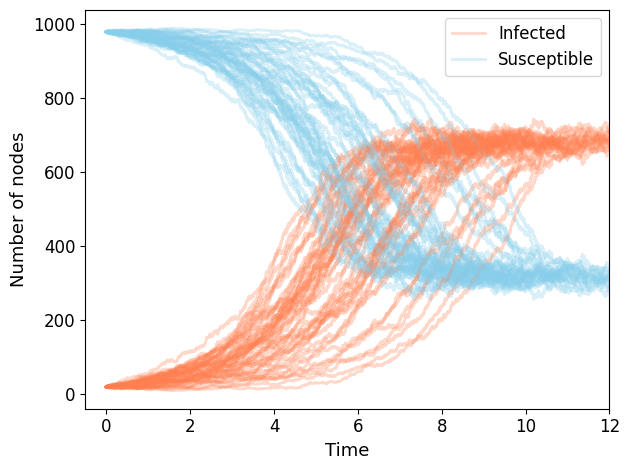

In [5]:
#################### Plotting the simulations

# Plot the first 50 Gillespie realisations
for j in range(50):
    t, S_, I_ = times_runs[j], S_runs[j], I_runs[j]
    # Plot infected (coral) and susceptible (blue) time series with transparency
    plt.plot(t, I_, lw=2, color='coral', alpha=0.3, label='Infected' if j == 0 else None)
    plt.plot(t, S_, lw=2, color='skyblue', alpha=0.3, label='Susceptible' if j == 0 else None)

plt.xlim((-0.5, 12))
plt.xlabel('Time', fontsize=13)
plt.ylabel('Number of nodes', fontsize=13)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

### Effective hyperdegree model 


Now we solve the effective hayperdegree model. 

The inputs are similar to the ones of the guillespie simualtions, this is, $\beta_1$ and $\beta_2$, the recovery rate $\mu$, the initial conditions (which nodes are initially infected), and the lists of edges and triangles.

It is worth noting that the list of edges and triangles is not used int eh same way as in the guillespie. For the effective model we need the list to establish the initial condition and have the initial nubmer node sin each hyperdegree category and hyeprdege state counts. Once the initial codnitions are established we dont directly use again the list of edges and triples. 



In [6]:
# --- Model parameters ---
N = 1000        # Number of nodes
mu = 1          # Recovery rate
k1 = 5        # Average pairwise degree
k2 = 3      # Average three-body degree

# Rescaled infection rates: lambda = beta * k / mu
lam1 = 1.5      # Pairwise spreading rate (relative to threshold)
lam2 = 3        # Three-body spreading rate (relative to threshold)
# Combine pairwise edges and triangles into a single hyperedge list
hyper_edges = [*edges, *triples]

# Convert to 1-indexed node labels (required by the effective degree solver)
hyper_new = []
for edge in hyper_edges:
    new_edge = []
    for ele in edge:
        new_edge.append(int(ele + 1))
    hyper_new.append(new_edge)

num_inf = 20  # Number of initially infected nodes

# Compute absolute infection rates from the rescaled parameters
beta1 = lam1 * mu / k1   # Pairwise infection rate
beta2 = lam2 * mu / k2   # Three-body infection rate
para = [beta1, beta2, mu]

# --- Solve the effective hyperdegree ODE model ---
# Returns the time evolution of susceptible/infected compartments
# grouped by hyperdegree class (k1, k2)
results_model_reg1 = odeint_effective_degree_HO_optimized(
    para, hyper_new, T=T, N=N,
    initial_infected=num_inf,
    steps_ode=1000
)
print('')
print('')

10102
-------
10102
Starting ultra-optimized integration...
Progress: 0.6% (t=0.246, dt=0.000450)
Progress: 1.5% (t=0.618, dt=0.001120)
Progress: 3.9% (t=1.571, dt=0.002786)
Progress: 8.0% (t=3.187, dt=0.003344)
Progress: 12.1% (t=4.859, dt=0.003344)
Progress: 16.3% (t=6.530, dt=0.003344)
Progress: 20.6% (t=8.233, dt=0.004012)
Progress: 31.1% (t=12.429, dt=0.010000)
Progress: 43.6% (t=17.429, dt=0.010000)
Progress: 56.1% (t=22.429, dt=0.010000)
Progress: 68.6% (t=27.429, dt=0.010000)
Progress: 81.1% (t=32.429, dt=0.010000)
Progress: 93.6% (t=37.429, dt=0.010000)
Integration completed in 6758 steps




Steady-state I: 689.5456


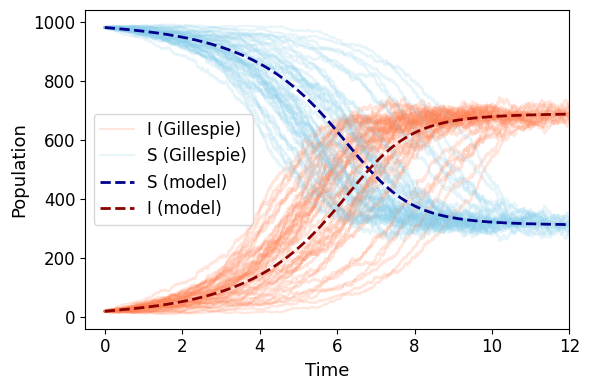

In [7]:
plt.figure(figsize=(6, 4))

# --- Gillespie realisations ---
# Plot the first 50 stochastic simulations as transparent traces
for j in range(50):
    t, S_, I_ = times_runs[j], S_runs[j], I_runs[j]
    plt.plot(t, I_, lw=1.5, color='coral', alpha=0.2, label='I (Gillespie)' if j == 0 else None)
    plt.plot(t, S_, lw=1.5, color='skyblue', alpha=0.2, label='S (Gillespie)' if j == 0 else None)

# --- Effective hyperdegree model ---
# Overlay the deterministic ODE solution as dashed lines
times, S, I = results_model_reg1
plt.plot(times, S, color='darkblue', ls='--', lw=2, label='S (model)')
plt.plot(times, I, color='darkred', ls='--', lw=2, label='I (model)')

# Print the steady-state infected fraction from the model
print(f'Steady-state I: {np.mean(I[-100:]):.4f}')

plt.xlim((-0.5, 12))
plt.xlabel('Time', fontsize=13)
plt.ylabel('Population', fontsize=13)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

# Checking for Heterogenouse networks 



In [8]:
'''Create the Hyergraph using the configurational model'''
N=1000
# Define the desired degree for pairwise (k1) and three-body (k2) interactions
gam1=2.5
gam2=2.25
# Create homogeneous degree sequences: every node has the same k1 and k2
sample_k1=generate_powerlaw_degrees(n=N,gamma=gam1, min_degree=2, max_degree=50)
sample_k2=generate_powerlaw_degrees(n=N,gamma=gam2, min_degree=1, max_degree=20)


# Shuffle the degree sequences (useful for the stub-matching process in the configurational model)
random.shuffle(sample_k1)
random.shuffle(sample_k2)

# Generate the hypergraph using the configurational model,
# returning pairwise edges and three-body (triangle) hyperedges
edges, triples = configurational_model_hypergraph(sample_k1, sample_k2, N)

# Combine pairwise and three-body interactions into a single list of hyperedges
hyper_edges = [*edges, *triples]

print(triples)

[[753, 423, 439], [218, 860, 440], [666, 276, 532], [526, 898, 959], [367, 677, 893], [859, 258, 288], [606, 976, 949], [772, 899, 168], [330, 109, 438], [397, 824, 195], [530, 802, 643], [643, 959, 175], [38, 579, 259], [704, 453, 446], [40, 803, 38], [340, 924, 95], [323, 552, 897], [625, 490, 340], [423, 26, 849], [151, 397, 877], [331, 371, 960], [803, 873, 786], [59, 514, 38], [792, 860, 415], [702, 472, 232], [666, 986, 272], [824, 294, 694], [660, 374, 850], [382, 168, 453], [180, 111, 615], [719, 832, 134], [996, 577, 296], [640, 465, 302], [860, 249, 774], [583, 245, 454], [461, 409, 528], [123, 19, 747], [444, 694, 661], [291, 83, 38], [344, 638, 468], [524, 900, 520], [910, 112, 824], [818, 20, 425], [209, 554, 745], [893, 554, 859], [190, 409, 253], [771, 754, 640], [749, 846, 666], [939, 175, 658], [489, 168, 107], [168, 666, 496], [337, 340, 725], [445, 775, 643], [812, 468, 947], [988, 446, 782], [482, 832, 59], [818, 657, 295], [619, 70, 592], [895, 680, 792], [524, 270

In [9]:
from datetime import datetime
start_time = datetime.now()

# --- Model parameters ---
N = 1000        # Number of nodes
mu = 1          # Recovery rate
k1 = 5        # Average pairwise degree
k2 = 3      # Average three-body degree

# Rescaled infection rates: lambda = beta * k / mu
lam1 = 1.5      # Pairwise spreading rate (relative to threshold)
lam2 = 3        # Three-body spreading rate (relative to threshold)

beta1 = lam1 * mu / k1   # Pairwise infection rate
beta2 = lam2 * mu / k2   # Three-body infection rate

# --- Simulation settings ---
iters = 100       # Number of independent Gillespie realisations
num_inf = 20      # Number of initially infected nodes per realisation
T = 40            # Maximum simulation time

# Pre-generate fixed initial conditions for reproducibility across runs
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)


# --- Run Gillespie simulations ---
# Returns time series of infected and susceptible counts across all realisations
times_runs, I_runs, S_runs = SIS_gillespie_temporal_evolution(
    N, beta1, beta2, mu,
    iters=iters,
    edges=np.array(edges),
    triangles=np.array(triples),
    fixed_init=fixed_init,
    t_max=T,
    check_interval=2000,
    variance_threshold=1e-4
)

# Extract the first realisation (e.g. for quick inspection)
all_sim = []
I = I_runs[0]

end_time = datetime.now()
print(f'Duration: {end_time - start_time}')

Duration: 0:00:21.902626


In [10]:
# --- Model parameters ---
N = 1000        # Number of nodes
mu = 1          # Recovery rate
k1 = 5        # Average pairwise degree
k2 = 3      # Average three-body degree

# Rescaled infection rates: lambda = beta * k / mu
lam1 = 1.5      # Pairwise spreading rate (relative to threshold)
lam2 = 3        # Three-body spreading rate (relative to threshold)
# Combine pairwise edges and triangles into a single hyperedge list
hyper_edges = [*edges, *triples]

# Convert to 1-indexed node labels (required by the effective degree solver)
hyper_new = []
for edge in hyper_edges:
    new_edge = []
    for ele in edge:
        new_edge.append(int(ele + 1))
    hyper_new.append(new_edge)

num_inf = 20  # Number of initially infected nodes

# Compute absolute infection rates from the rescaled parameters
beta1 = lam1 * mu / k1   # Pairwise infection rate
beta2 = lam2 * mu / k2   # Three-body infection rate
para = [beta1, beta2, mu]

# --- Solve the effective hyperdegree ODE model ---
# Returns the time evolution of susceptible/infected compartments
# grouped by hyperdegree class (k1, k2)
results = odeint_effective_degree_HO_optimized(
    para, hyper_new, T=T, N=N,
    initial_infected=num_inf,
    steps_ode=1000,
    use_fast_derivatives=True
)
print('')
print('')

45042
-------
45042
Starting ultra-optimized integration...
Progress: 0.3% (t=0.118, dt=0.000078)
Progress: 0.4% (t=0.178, dt=0.000135)
Progress: 0.7% (t=0.267, dt=0.000233)
Progress: 1.0% (t=0.397, dt=0.000280)
Progress: 1.4% (t=0.573, dt=0.000403)
Progress: 2.0% (t=0.798, dt=0.000484)
Progress: 2.7% (t=1.069, dt=0.000580)
Progress: 3.5% (t=1.405, dt=0.000697)
Progress: 4.4% (t=1.753, dt=0.000697)
Progress: 5.3% (t=2.102, dt=0.000836)
Progress: 6.3% (t=2.520, dt=0.000836)
Progress: 7.7% (t=3.067, dt=0.001444)
Progress: 10.3% (t=4.128, dt=0.002995)
Progress: 16.3% (t=6.538, dt=0.008943)
Progress: 28.8% (t=11.534, dt=0.010000)
Progress: 41.3% (t=16.534, dt=0.010000)
Progress: 53.8% (t=21.534, dt=0.010000)
Progress: 66.3% (t=26.534, dt=0.010000)
Progress: 78.8% (t=31.534, dt=0.010000)
Progress: 91.3% (t=36.534, dt=0.010000)
Integration completed in 10000 steps




Steady-state I: 626.1616


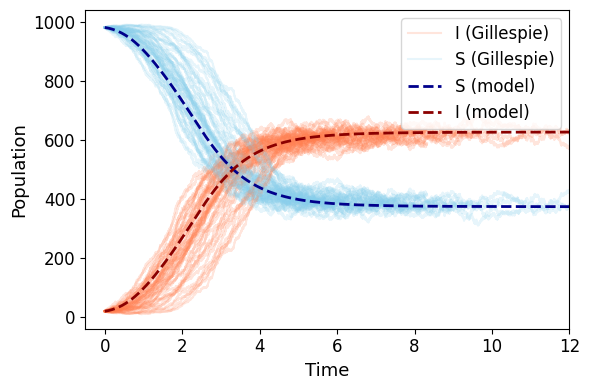

In [11]:
plt.figure(figsize=(6, 4))

# --- Gillespie realisations ---
# Plot the first 50 stochastic simulations as transparent traces
for j in range(50):
    t, S_, I_ = times_runs[j], S_runs[j], I_runs[j]
    plt.plot(t, I_, lw=1.5, color='coral', alpha=0.2, label='I (Gillespie)' if j == 0 else None)
    plt.plot(t, S_, lw=1.5, color='skyblue', alpha=0.2, label='S (Gillespie)' if j == 0 else None)

# --- Effective hyperdegree model ---
# Overlay the deterministic ODE solution as dashed lines
times, S, I = results
plt.plot(times, S, color='darkblue', ls='--', lw=2, label='S (model)')
plt.plot(times, I, color='darkred', ls='--', lw=2, label='I (model)')

# Print the steady-state infected fraction from the model
print(f'Steady-state I: {np.mean(I[-100:]):.4f}')

plt.xlim((-0.5, 12))
plt.xlabel('Time', fontsize=13)
plt.ylabel('Population', fontsize=13)
plt.legend(fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

## Phase diagram

To construct the phase diagram we vary the value of $\lambda_1$ and calcualte 

In [ ]:
'''Create the Hyergraph using the configurational model'''
# Define the desired degree for pairwise (k1) and three-body (k2) interactions
k1 = 5
k2 = 3
N = 1000  # Number of nodes in the hypergraph

# Create homogeneous degree sequences: every node has the same k1 and k2
sample_k1=np.random.poisson(lam=k1,size=N)
sample_k2=np.random.poisson(lam=k2,size=N)

# Shuffle the degree sequences (useful for the stub-matching process in the configurational model)
random.shuffle(sample_k1)
random.shuffle(sample_k2)

# Generate the hypergraph using the configurational model,
# returning pairwise edges and three-body (triangle) hyperedges
edges, triples = configurational_model_hypergraph(sample_k1, sample_k2, N)

# Combine pairwise and three-body interactions into a single list of hyperedges
hyper_edges = [*edges, *triples]

print(triples)


In [ ]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,2,50)
lambdas = lambdas[::3]


#N=500
N=1000
k1=5
k2=3
lam2=2.5
mu=1
beta2=lam2*mu/k2

iters=100
num_inf=800
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]
T=200

init_infec=np.random.choice(range(0,N-1),size=init_infec_num)

prevalences=[]
I_steady_states2=[]
for lam in lambdas:
    beta1=lam*mu/k1
#I, times_sim, I_links, I_hyperedges, times_links, times_hyperedges=SIS_gillespie_HO(N, beta1, beta2, mu, edges=pairs, triangles=triples, init_infec=init_infec, t_max=T)
    Itimes_runs, I_runs, S_runs=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=np.array(edges), triangles=np.array(triples), fixed_init=fixed_init, t_max=T, check_interval=1000, variance_threshold=1e-6)
    
    all_sim=[]
    epidemic_size=[]
    for i in range (len(I_runs)):
        I=I_runs[i]
        times=times_runs[i]
        #minio_helper.save_file(f'Simulation_Poisson_HO_alpha0/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim_arr, obj_type='csv' )
        epidemic_size.append(np.mean(I[-100:]))
        #np.savetxt(f'poisson_simulation/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim)

    
    I_steady_states2.append(epidemic_size)
    print(f'Lambda=  {lam}, Epidemic_size = {np.mean(epidemic_size)}, final time {times[-1]} ')

    prevalences.append(np.mean(epidemic_size))
#data_runs=[times_runs,I_runs]
#data_runs_arr=np.array(data_runs, dtype=object)
#file_name=f'sim_N{N}_k1{k1}_k2{k2}'
#np.savetxt('regular_simulation/'+file_name+'.txt',data_sim)

#minio_helper.save_file(f'Simulation_Poisson_HO/sim_N{N}_k1{k1}_k2{k2}'+f'_I_ss'+'.txt',pd.DataFrame(I_steady_states1), obj_type='csv' )
#minio_helper.save_file(f'Simulation_Poisson_HO/sim_N{N}_k1{k1}_k2{k2}'+f'_prev_reverse'+'.txt',pd.DataFrame(prevalences), obj_type='csv' )
end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))



In [ ]:
def odeint_effective_degree_HO_phase_diagram_optimized(para, lambdas, hyperedges, initial_infected=None, N=1000,T=20, steps=2000):
    
    prevalence=[]
    aux, beta2, k1, k2, gamma = para
    for i in range (len(lambdas)):
        lam1=lambdas[i]
        beta1=lam1*gamma/k1
        para=[beta1,beta2,gamma]
        times, S_t, I_t= odeint_effective_degree_HO_optimized(para,hyper_new,T=T,N=N,initial_infected=initial_infected,steps_ode=steps)

        plt.show()
        prevalence.append(np.mean(I_t[-100:]))
        print('Lambda ', lam1)
        print('Prev ', prevalence[-1], times[-1])
        print('---')
        
    return prevalence